# 1. Đọc dữ liệu và nghiệm thu quá trình Missing value và Outlier

 Đã tải tập TRAIN thành công! Kích thước bộ dữ liệu: (4645, 26)
 Đã tải tập TEST thành công! Kích thước bộ dữ liệu: (1164, 26)

BẢNG THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU (MISSING VALUES)
                    Train Missing  Train Tỷ lệ (%)  Test Missing  \
Dien_Tich_Lo                  961            20.69           226   
Ty_Le_Giao_Thong              967            20.82           229   
Ty_Le_Cong_Cong_CX            967            20.82           229   
Ty_Le_Khac                    967            20.82           229   
Ty_Le_Dat_O                   967            20.82           229   

                    Test Tỷ lệ (%)  
Dien_Tich_Lo                 19.42  
Ty_Le_Giao_Thong             19.67  
Ty_Le_Cong_Cong_CX           19.67  
Ty_Le_Khac                   19.67  
Ty_Le_Dat_O                  19.67  


 Đang vẽ Boxplot cho 26 cột số học của tập TRAIN...


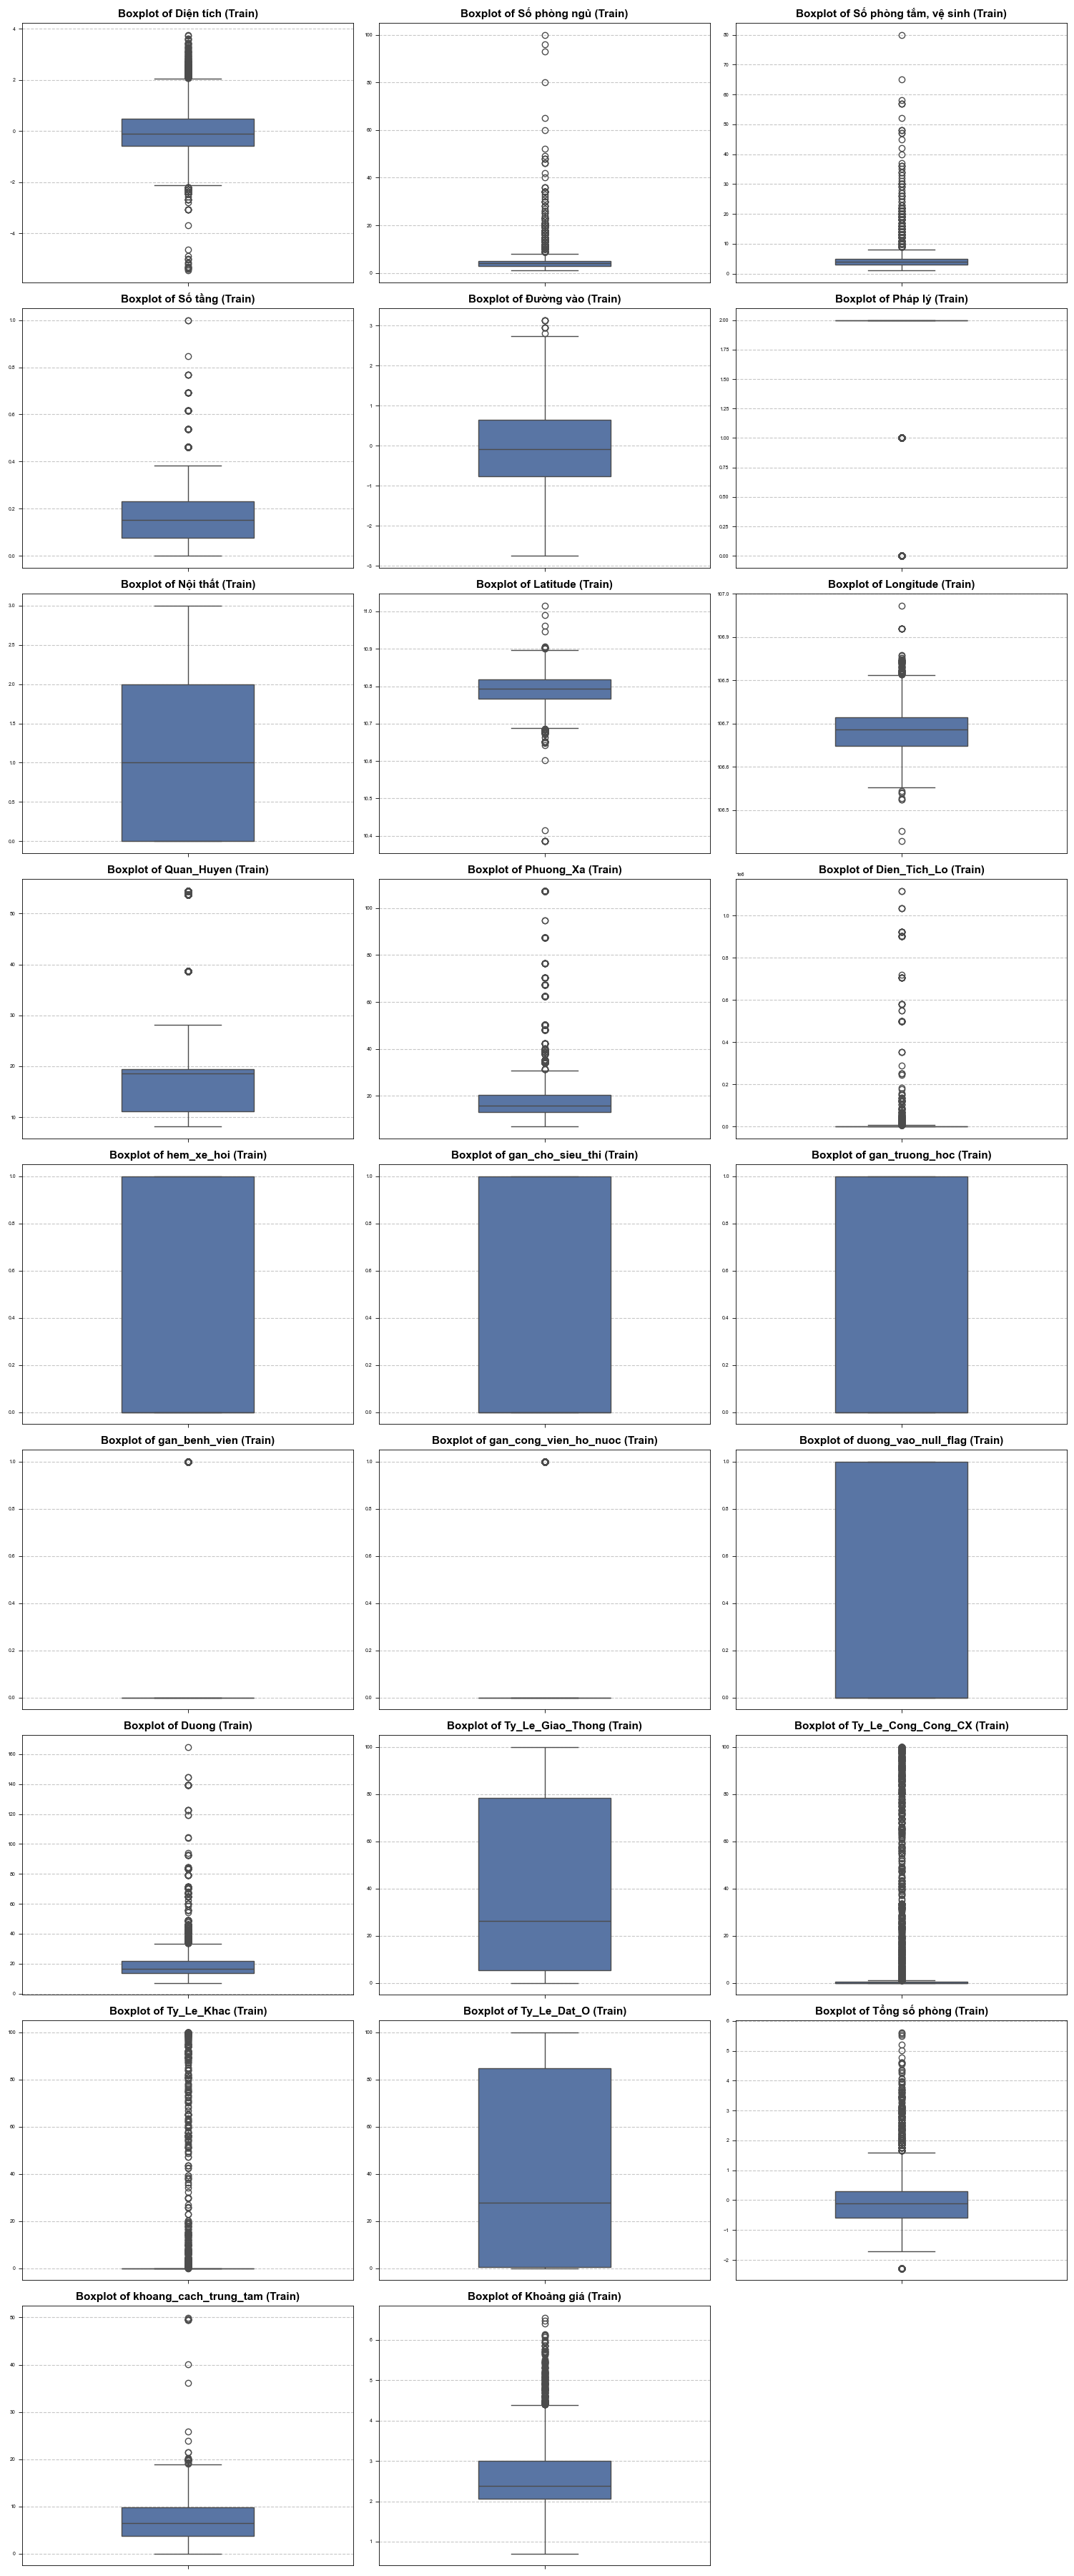

In [109]:
# =======================================================================
# CELL: DATA LOADING, MISSING VALUE ANALYSIS, AND TRAIN BOXPLOTS
# =======================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -------------------------------------------------------------------------
# 1. ĐỌC DỮ LIỆU CẢ HAI TẬP (TRAIN & TEST)
# -------------------------------------------------------------------------
# Đường dẫn file Train của bạn
file_path_train = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/Đồ án/DS108/notebook/data_output/3_data_preprocessed_linear_train.csv"
# Tự động suy luận đường dẫn tập Test (Bạn có thể sửa lại tên file nếu khác)
file_path_test = "/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/Đồ án/DS108/notebook/data_output/3_data_preprocessed_linear_test.csv"

df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

print(
    f" Đã tải tập TRAIN thành công! Kích thước bộ dữ liệu: {df_train.shape}"
)
print(f" Đã tải tập TEST thành công! Kích thước bộ dữ liệu: {df_test.shape}\n")


# -------------------------------------------------------------------------
# 2. THỐNG KÊ SO SÁNH GIÁ TRỊ KHUYẾT THIẾU (TRAIN VS TEST)
# -------------------------------------------------------------------------
print("=" * 70)
print("BẢNG THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU (MISSING VALUES)")
print("=" * 70)

# Tính toán cho tập Train
missing_count_train = df_train.isnull().sum()
missing_percent_train = (df_train.isnull().sum() / len(df_train)) * 100

# Tính toán cho tập Test
missing_count_test = df_test.isnull().sum()
missing_percent_test = (df_test.isnull().sum() / len(df_test)) * 100

# Gộp chung thành một bảng để dễ dàng đối chiếu song song
missing_df_train = pd.DataFrame(
    {
        "Train Missing": missing_count_train,
        "Train Tỷ lệ (%)": missing_percent_train.round(2),
        "Test Missing": missing_count_test,
        "Test Tỷ lệ (%)": missing_percent_test.round(2),
    }
)

# Lọc ra các cột có khuyết thiếu ở ít nhất một trong hai tập dữ liệu
has_missing = (missing_df_train["Train Missing"] > 0) | (
    missing_df_train["Test Missing"] > 0
)

if not has_missing.any():
    print(
        " Chúc mừng! Cả hai bộ dữ liệu (Train & Test) đều sạch sẽ, không có giá trị khuyết thiếu."
    )
else:
    print(missing_df_train[has_missing])
print("\n" + "=" * 70 + "\n")


# -------------------------------------------------------------------------
# 3. TRỰC QUAN HÓA BOXPLOT CHO TẤT CẢ CÁC CỘT SỐ HỌC (CHỈ VẼ TRÊN TẬP TRAIN)
# -------------------------------------------------------------------------
# Lọc ra danh sách các cột số học từ tập Train
num_cols = df_train.select_dtypes(include=["number"]).columns

if len(num_cols) > 0:
    print(f" Đang vẽ Boxplot cho {len(num_cols)} cột số học của tập TRAIN...")

    # Cấu hình lưới hiển thị biểu đồ (Mặc định mỗi hàng có tối đa 3 biểu đồ)
    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
    )
    axes = axes.flatten()

    # Vòng lặp vẽ boxplot cho từng cột dữ liệu Train
    for i, col in enumerate(num_cols):
        sns.boxplot(
            data=df_train, y=col, ax=axes[i], color="#4C72B0", width=0.4
        )
        axes[i].set_title(
            f"Boxplot of {col} (Train)", fontsize=11, fontweight="bold"
        )
        axes[i].set_ylabel("")  # Ẩn label trục Y để biểu đồ gọn gàng hơn
        axes[i].grid(axis="y", linestyle="--", alpha=0.7)

    # Ẩn các ô biểu đồ thừa nếu số lượng cột không chia hết cho n_cols
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print(
        " Không tìm thấy cột dữ liệu số học (Numerical) nào ở tập Train để vẽ Boxplot!"
    )

Đối với bộ dữ liệu được tiền xử lý cho mô hình cây thì các thuộc tính bị khuyết thiếu nằm trong sặp đặt của bước clean đều đảm bản tính đủ của dữ liệu vì các mô hình này tận dụng được thông tin khuyết thiếu của dữ liệu (MNAR) để suuy luận.

- Missing value được xử lý sạch sẽ. Những Missing tồn tại được chủ động để lại cho mô hình học.
- Các outlier đang nằm trong vùng không vô ly, các outlier vô lý đã bọ loại bỏ.

# 2. Phân phối biến mục tiêu

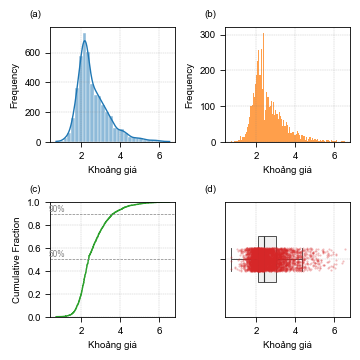

In [110]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -------------------------------------------------------------------------
# 1. PUBLICATION SETTINGS (IEEE Standard)
# -------------------------------------------------------------------------
# Set font Arial, 7pt size globally
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,      # Thin axes
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'lines.linewidth': 1.0      # Thin lines to fit small column width
})

target = 'Khoảng giá'
plot_data = pd.to_numeric(df_train[target], errors='coerce').dropna()

# -------------------------------------------------------------------------
# 2. FIGURE INITIALIZATION
# -------------------------------------------------------------------------
# IEEE single-column width is typically 3.5 inches. 
# Height is set to 3.5 inches to form a compact 2x2 square grid.
fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.5))

# Academic-friendly colors (distinct but not overly saturated)
color_a = '#1f77b4' # Muted Blue
color_b = '#ff7f0e' # Safety Orange
color_c = '#2ca02c' # Forest Green
color_d_box = '#f0f0f0' 
color_d_strip = '#d62728' # Brick Red

# --- (a) Histogram + KDE ---
sns.histplot(plot_data, kde=True, ax=axes[0, 0], color=color_a, edgecolor='white', linewidth=0.3, bins=30)
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlabel(target)

# --- (b) High-bin Histogram (Bins=100) ---
sns.histplot(plot_data, ax=axes[0, 1], color=color_b, edgecolor='none', bins=100)
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlabel(target)

# --- (c) ECdf_train Plot ---
sns.ecdfplot(plot_data, ax=axes[1, 0], color=color_c)
axes[1, 0].axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
axes[1, 0].axhline(0.9, color='gray', linestyle='--', linewidth=0.5)
axes[1, 0].text(plot_data.max() * 0.05, 0.52, '50%', color='gray', fontsize=6)
axes[1, 0].text(plot_data.max() * 0.05, 0.92, '90%', color='gray', fontsize=6)
axes[1, 0].set_ylabel('Cumulative Fraction')
axes[1, 0].set_xlabel(target)

# --- (d) Boxplot + Stripplot ---
sns.boxplot(x=plot_data, ax=axes[1, 1], color=color_d_box, showfliers=False, width=0.4, 
            boxprops=dict(edgecolor='#333333', linewidth=0.6), 
            whiskerprops=dict(color='#333333', linewidth=0.6),
            capprops=dict(color='#333333', linewidth=0.6),
            medianprops=dict(color='#333333', linewidth=0.8))
# Marker size (size=1.5) reduced to prevent ink bleeding in small charts
sns.stripplot(x=plot_data, ax=axes[1, 1], color=color_d_strip, alpha=0.3, size=1.5, jitter=True)
axes[1, 1].set_xlabel(target)

# -------------------------------------------------------------------------
# 3. LABELS & EXPORT
# -------------------------------------------------------------------------
labels = ['(a)', '(b)', '(c)', '(d)']

for i, ax in enumerate(axes.flatten()):
    ax.grid(axis='both', linestyle='--', linewidth=0.3, alpha=0.5, color='gray')
    
    # Place (a), (b), (c), (d) outside top-left.
    # Adjusted xytext to (-15, 6) because the figure is smaller.
    ax.annotate(labels[i], xy=(0, 1), xycoords="axes fraction", 
                xytext=(-15, 6), textcoords="offset points", 
                fontsize=7, ha="left", va="bottom")

# Apply tight layout with small padding to maximize space
plt.tight_layout(pad=0.5, w_pad=1.0, h_pad=1.0)

# Export standard: PNG format, 300 DPI, tight bounding box
plt.savefig('target_distribution_ieee.png', dpi=300, format='png', bbox_inches='tight')

plt.show()

# 3. Phân tích tương quan sau tiền xử lý.

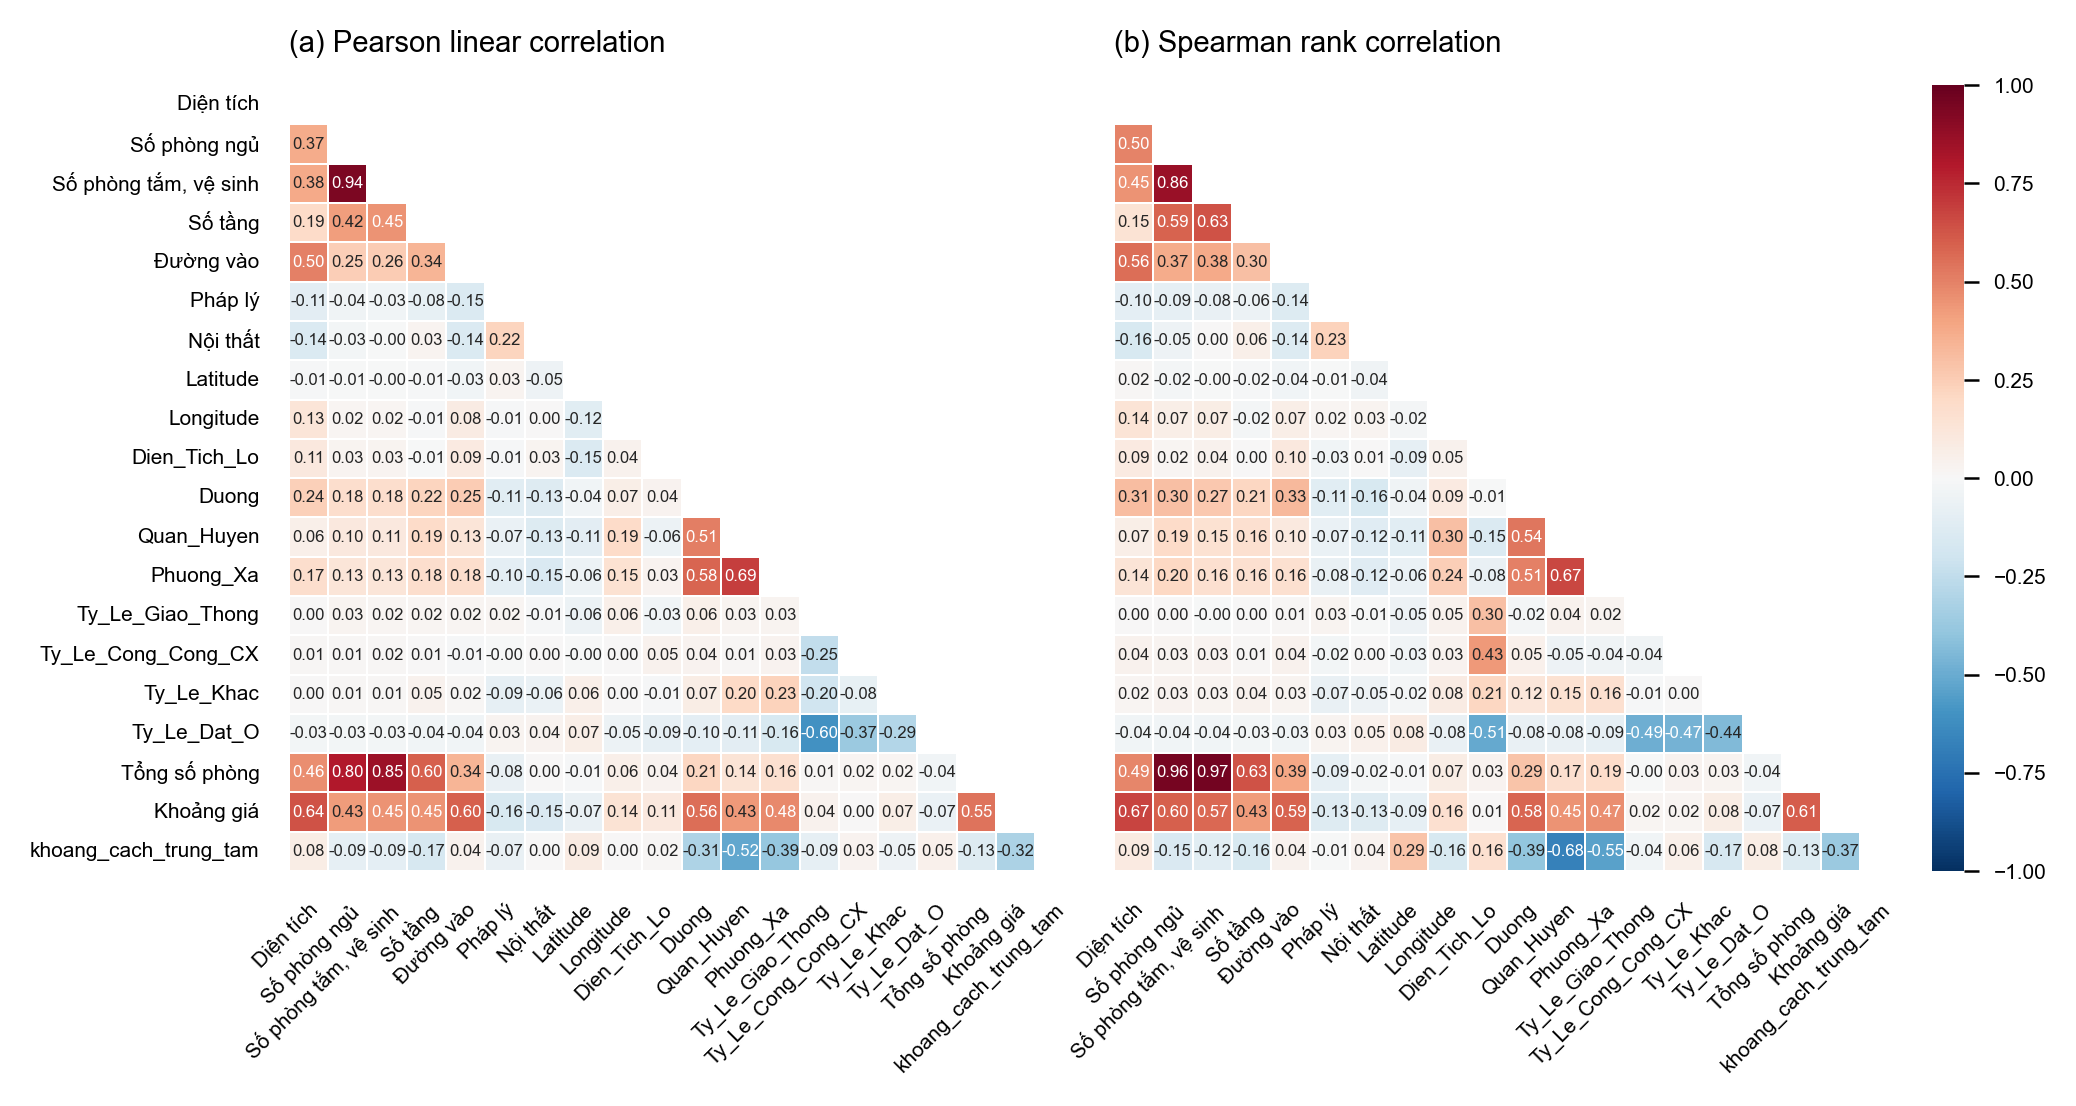

In [111]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: MA TRẬN TƯƠNG QUAN (IEEE DOUBLE COLUMN - 20 VARIABLES)
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. KHAI BÁO DANH SÁCH BIẾN VÀ LỌC DỮ LIỆU
# -------------------------------------------------------------------------
cols_to_corr = [
    'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng',       
    'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 
    'Dien_Tich_Lo', 'Duong', 'Quan_Huyen', 'Phuong_Xa', 
    'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac', 
    'Ty_Le_Dat_O', 'Tổng số phòng', 'Khoảng giá', 'khoang_cach_trung_tam'
]

# Ép kiểu về số và bỏ qua lỗi chữ (Giả định biến df_train đã có sẵn từ các cell trước)
df_train_corr = df_train[cols_to_corr].apply(pd.to_numeric, errors='coerce')

# Tính toán 2 loại ma trận tương quan
corr_pearson = df_train_corr.corr(method='pearson')
corr_spearman = df_train_corr.corr(method='spearman')

# Tạo mặt nạ che nửa tam giác trên
mask_pearson = np.triu(np.ones_like(corr_pearson, dtype=bool))
mask_spearman = np.triu(np.ones_like(corr_spearman, dtype=bool))

# -------------------------------------------------------------------------
# 2. CẤU HÌNH TYPOGRAPHY & FIGURE THEO CHUẨN IEEE
# -------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,      # ĐÃ SỬA: Đổi pdf_train thành pdf
    'ps.fonttype': 42,
    'font.size': 6,          
    'axes.titlesize': 7,     
    'xtick.labelsize': 5,    # Cỡ chữ siêu nhỏ cho 20 biến
    'ytick.labelsize': 5,    
})

# Khởi tạo 2 subplots đối xứng, sharey=True để dùng chung trục Y bên trái
fig, axes = plt.subplots(1, 2, figsize=(7.16, 5.5), dpi=300, sharey=True)

# Cấu hình chung cho Heatmap (Dùng RdBu_r cho học thuật)
heatmap_kwargs = {
    'cmap': 'RdBu_r', 
    'vmin': -1.0, 
    'vmax': 1.0, 
    'center': 0,
    'square': True, 
    'linewidths': 0.1,            # Viền cực mỏng để tiết kiệm không gian
    'linecolor': 'white',
    'annot': True,               
    'fmt': '.2f',                
    'annot_kws': {"size": 4},     # Cỡ chữ số trong ô siêu nhỏ (4pt)
    'cbar': False                 # Tắt colorbar ở cả 2 hình để căn đều kích thước
}

# --- SUBPLOT (a): Pearson ---
sns.heatmap(corr_pearson, mask=mask_pearson, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('(a) Pearson linear correlation', loc='left', pad=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].tick_params(bottom=False, left=False)

# --- SUBPLOT (b): Spearman ---
sns.heatmap(corr_spearman, mask=mask_spearman, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('(b) Spearman rank correlation', loc='left', pad=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
axes[1].tick_params(bottom=False, left=False)

# Căn chỉnh khung trước khi gắn Colorbar
plt.subplots_adjust(left=0.15, right=0.90, top=0.92, bottom=0.25, wspace=0.05)

# -------------------------------------------------------------------------
# 3. ÉP TỌA ĐỘ COLORBAR BẰNG NHAU TUYỆT ĐỐI KHÍT 100%
# -------------------------------------------------------------------------
fig.canvas.draw()
pos1 = axes[1].get_position(original=False)

# Tạo trục colorbar độc lập, cao chính xác bằng hình (b)
cax = fig.add_axes([pos1.x1 + 0.015, pos1.y0, 0.015, pos1.height])

# Gắn thanh màu vào trục vừa tạo
cbar = fig.colorbar(axes[1].collections[0], cax=cax)
cbar.ax.tick_params(labelsize=5)
cbar.outline.set_visible(False)

# 4. LƯU & HIỂN THỊ
plt.savefig('correlation_20_vars_ieee.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

Đang vẽ Scatter Plots cho 4645 dòng dữ liệu hợp lệ...



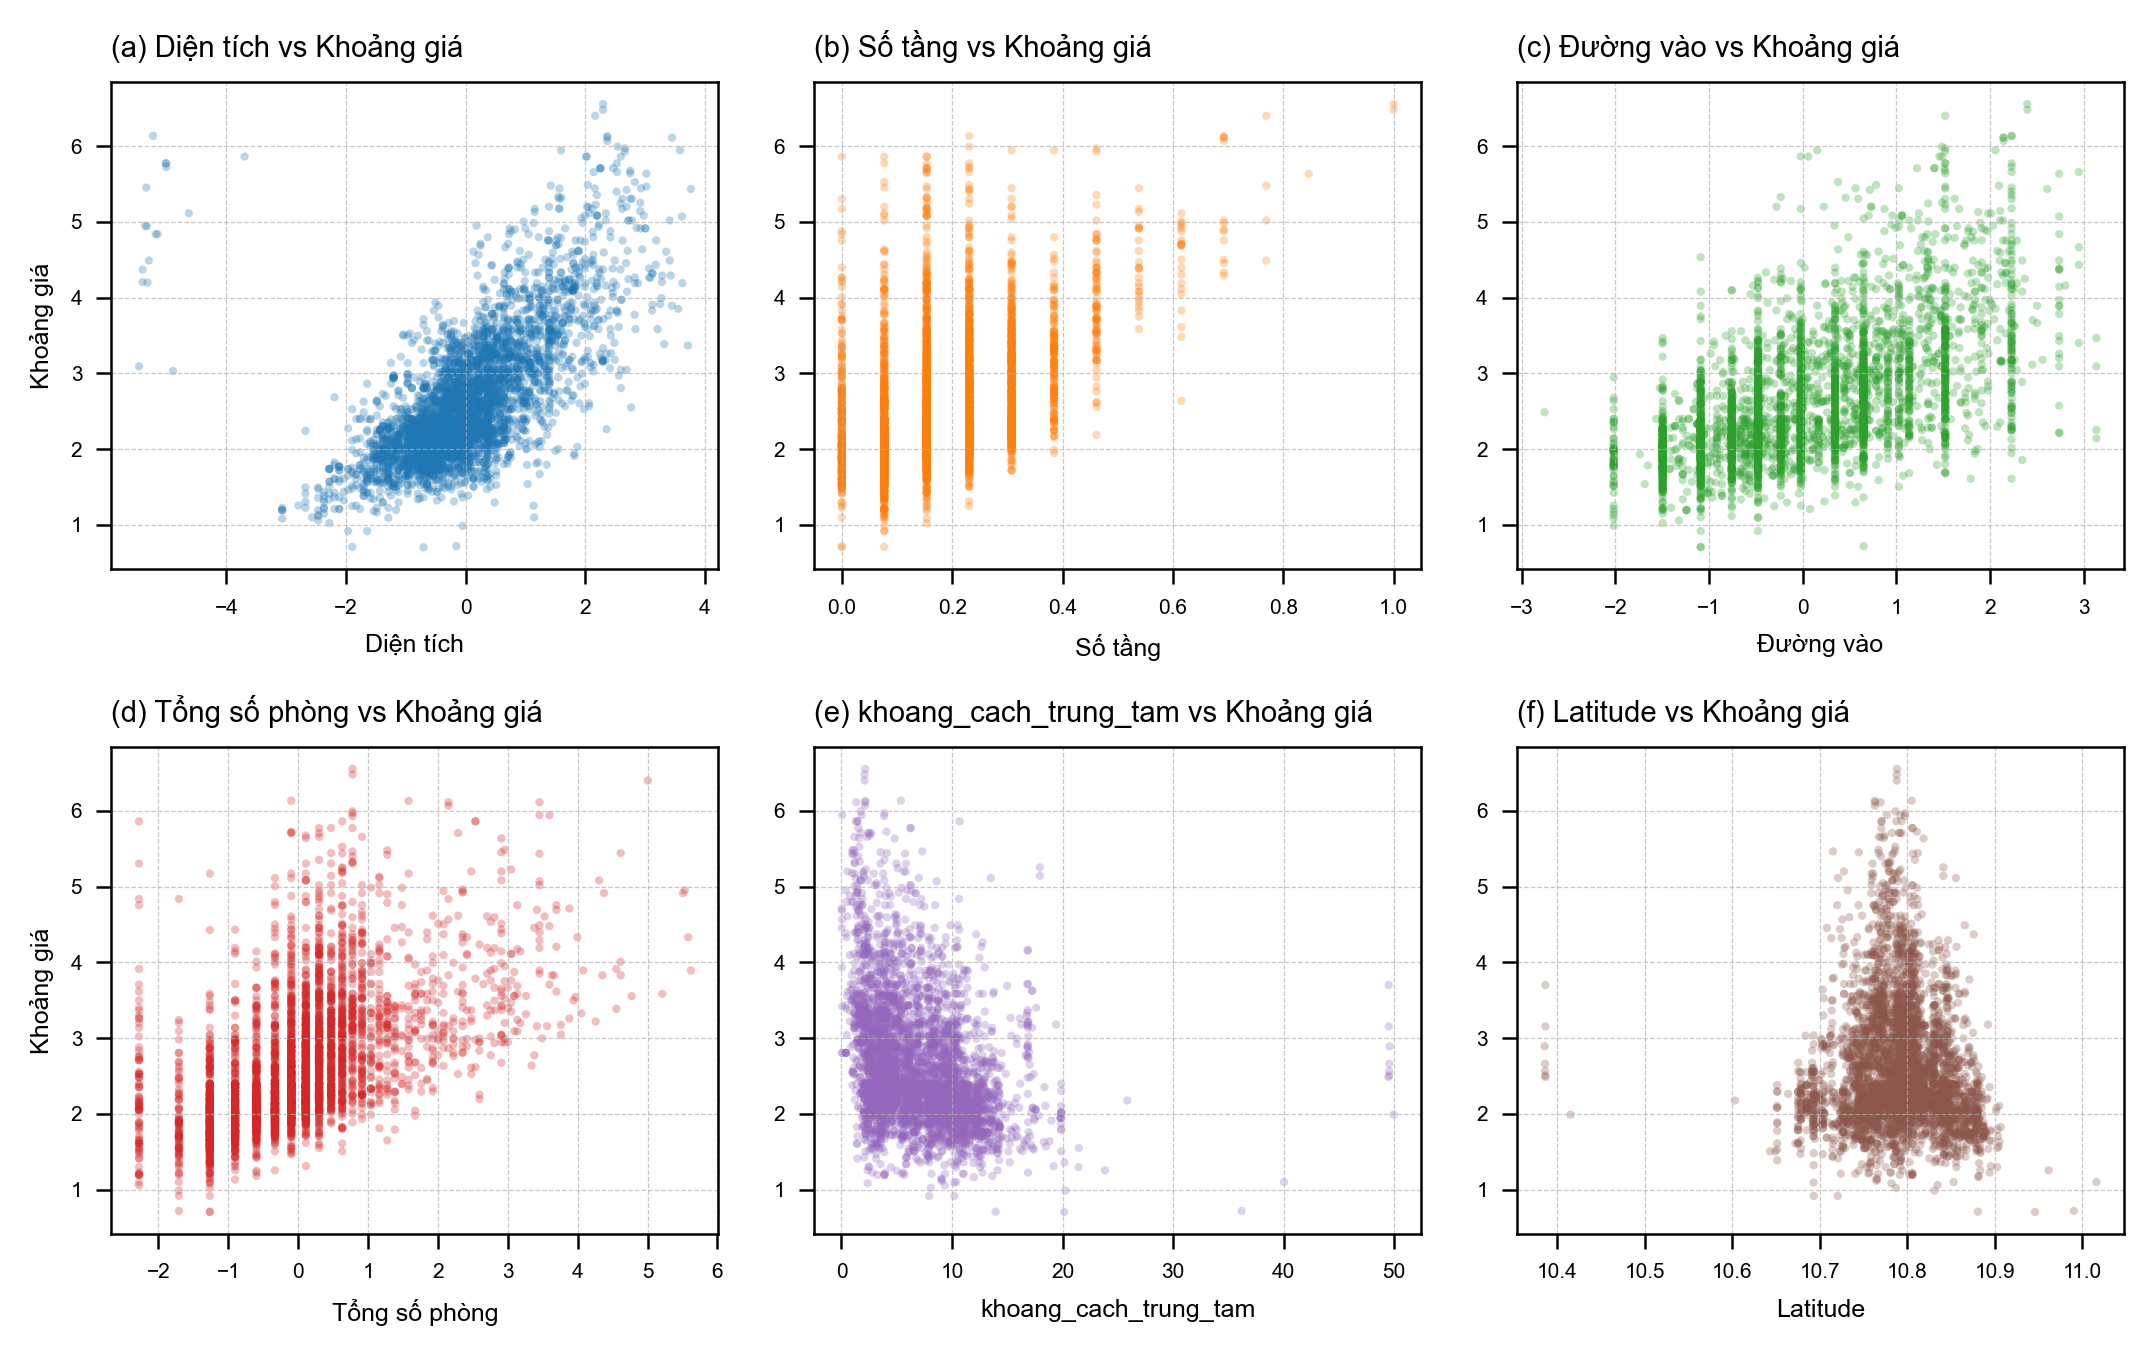

In [112]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: SCATTER PLOTS (IEEE DOUBLE COLUMN - TỐI ƯU TIÊU ĐỀ - PNG 300DPI)
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -------------------------------------------------------------------------
# 1. CHUẨN BỊ DỮ LIỆU
# -------------------------------------------------------------------------
target = 'Khoảng giá'
features = ['Diện tích', 'Số tầng', 'Đường vào', 'Tổng số phòng', 'khoang_cach_trung_tam', 'Latitude']

# Lấy các cột cần thiết và loại bỏ dòng có giá trị NaN
plot_data = df_train[features + [target]].copy()

# Ép kiểu về dạng số thực
for col in plot_data.columns:
    plot_data[col] = pd.to_numeric(plot_data[col], errors='coerce')

plot_data = plot_data.dropna()

print(f"Đang vẽ Scatter Plots cho {len(plot_data)} dòng dữ liệu hợp lệ...\n")

# -------------------------------------------------------------------------
# 2. CẤU HÌNH TYPOGRAPHY & FIGURE (CHUẨN HỌC THUẬT IEEE)
# -------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 6,          
    'axes.titlesize': 7,     # Cỡ chữ tiêu đề
    'axes.labelsize': 6,
    'xtick.labelsize': 5,    
    'ytick.labelsize': 5,    
})

# Khởi tạo khung 2x3 vừa đúng chiều rộng giấy 2 cột (7.16 inch)
fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.5), dpi=300)
axes = axes.flatten()

# 6 màu cho 6 biến
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# Lặp qua từng biến để vẽ
for i, feature in enumerate(features):
    sns.scatterplot(
        data=plot_data, 
        x=feature, 
        y=target, 
        color=colors[i],
        alpha=0.3,         
        edgecolor='none',  
        s=4,               
        ax=axes[i]
    )
    
    # GIỮ NGUYÊN ĐỊNH DẠNG TÊN BIẾN KHAI BÁO
    # Kết quả sẽ có dạng: (a) Diện tích vs Khoảng giá, (e) khoang_cach_trung_tam vs Khoảng giá
    short_title = f"{letters[i]} {feature} vs {target}"
    
    # Tiêu đề không in đậm, nằm ở góc trên bên trái
    axes[i].set_title(short_title, loc='left', pad=6)
    
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(f'{target}' if i % 3 == 0 else '') 
    axes[i].grid(axis='both', linestyle='--', linewidth=0.3, alpha=0.7)

# Căn chỉnh khoảng cách giữa các biểu đồ
plt.tight_layout(w_pad=2.0, h_pad=1.5)

# -------------------------------------------------------------------------
# 3. LƯU ẢNH PNG VÀ HIỂN THỊ
# -------------------------------------------------------------------------
plt.savefig('scatter_plots_ieee.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

Đang tính toán điểm Mutual Information (MI). Vui lòng đợi...



/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/3905684397.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette="viridis")


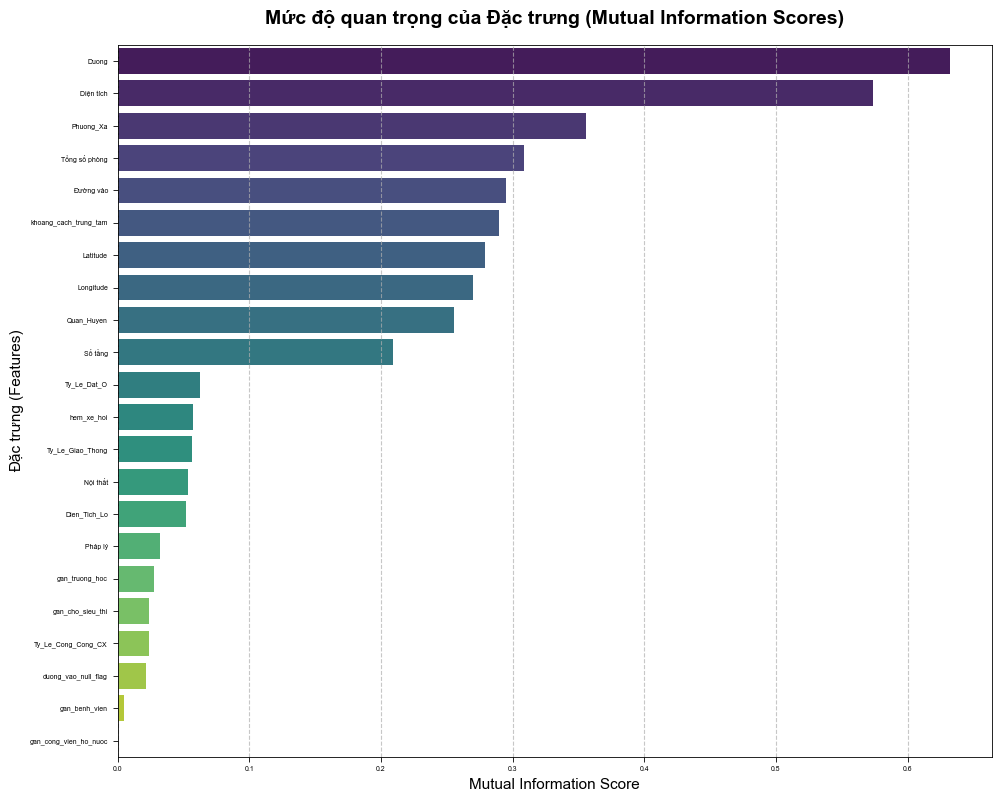

                       MI Scores
Duong                     0.6325
Diện tích                 0.5734
Phuong_Xa                 0.3560
Tổng số phòng             0.3089
Đường vào                 0.2952
khoang_cach_trung_tam     0.2894
Latitude                  0.2791
Longitude                 0.2697
Quan_Huyen                0.2557
Số tầng                   0.2088
Ty_Le_Dat_O               0.0626
hem_xe_hoi                0.0570
Ty_Le_Giao_Thong          0.0567
Nội thất                  0.0538
Dien_Tich_Lo              0.0520
Pháp lý                   0.0318
gan_truong_hoc            0.0274
gan_cho_sieu_thi          0.0237
Ty_Le_Cong_Cong_CX        0.0236
duong_vao_null_flag       0.0215
gan_benh_vien             0.0045
gan_cong_vien_ho_nuoc     0.0005


In [113]:
# =======================================================================
# CELL 4: FEATURE SELECTION - MUTUAL INFORMATION (THÔNG TIN TƯƠNG HỖ)
# =======================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

print("Đang tính toán điểm Mutual Information (MI). Vui lòng đợi...\n")

# 1. CHUẨN BỊ DỮ LIỆU (Bảo vệ df_train gốc)
target_col = 'Khoảng giá'

# Loại bỏ các biến đa cộng tuyến hoặc dư thừa đã phân tích trước đó (nếu chúng vẫn còn trong df_train)
cols_to_drop = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Ty_Le_Khac']
cols_to_drop = [c for c in cols_to_drop if c in df_train.columns]

X_mi = df_train.drop(columns=[target_col] + cols_to_drop).copy()
y_mi = df_train[target_col].copy()

# Xử lý khuyết thiếu tạm thời (để sklearn không báo lỗi)
for col in X_mi.select_dtypes(include=['number']).columns:
    X_mi[col] = X_mi[col].fillna(X_mi[col].median())

# Mã hóa các biến phân loại (Categorical -> Numeric)
cat_cols = X_mi.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X_mi[col] = X_mi[col].fillna('Unknown')
    X_mi[col] = LabelEncoder().fit_transform(X_mi[col])

# 2. TÍNH TOÁN MUTUAL INFORMATION
# Đánh dấu các biến rời rạc (discrete) để thuật toán MI tính toán chính xác hơn
discrete_features = X_mi.dtypes == int
mi_scores = mutual_info_regression(X_mi, y_mi, discrete_features=discrete_features, random_state=42)

# Chuyển kết quả thành Series và sắp xếp giảm dần
mi_scores_series = pd.Series(mi_scores, name="MI Scores", index=X_mi.columns)
mi_scores_series = mi_scores_series.sort_values(ascending=False)

# 3. TRỰC QUAN HÓA KẾT QUẢ
plt.figure(figsize=(10, 8))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette="viridis")
plt.title("Mức độ quan trọng của Đặc trưng (Mutual Information Scores)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mutual Information Score", fontsize=11)
plt.ylabel("Đặc trưng (Features)", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu chi tiết
print(mi_scores_series.to_frame().round(4))

# 4. Kiểm định lại thuật toán

Đang huấn luyện mô hình Random Forest nháp để chấm điểm Đặc trưng...



/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/350934847.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_scores_series.values, y=rf_scores_series.index, palette="mako")


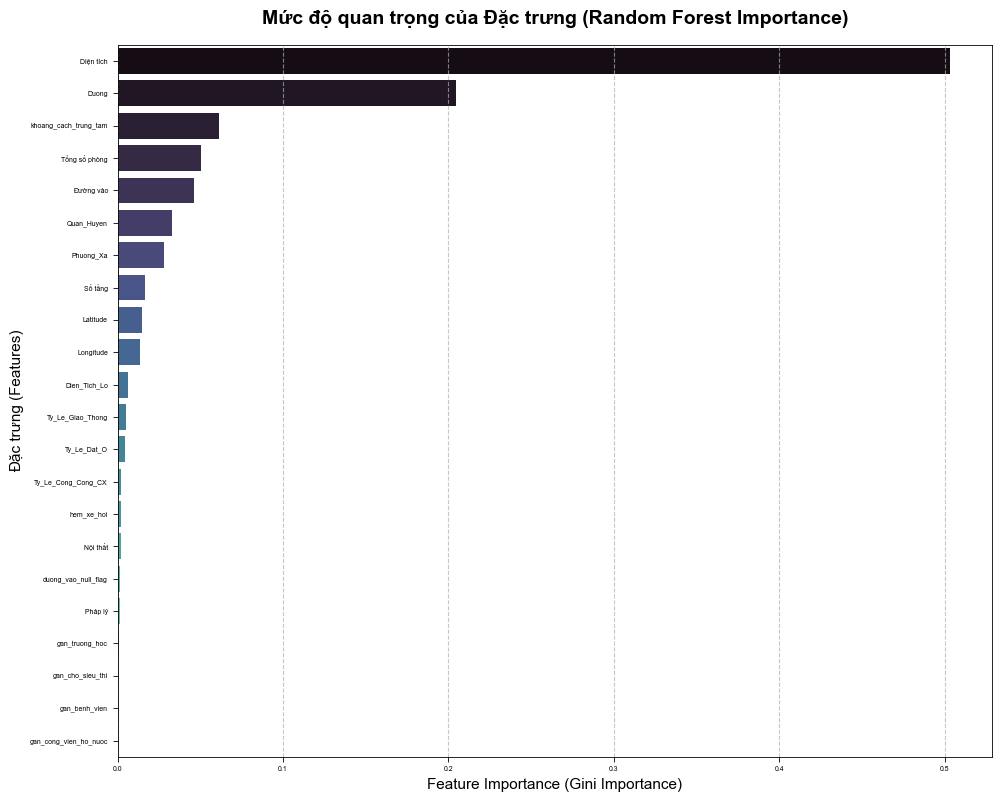

BẢNG TỔNG HỢP TOP ĐẶC TRƯNG TỪ RANDOM FOREST:
                       RF Importance
Diện tích                     0.5034
Duong                         0.2048
khoang_cach_trung_tam         0.0610
Tổng số phòng                 0.0504
Đường vào                     0.0464
Quan_Huyen                    0.0329
Phuong_Xa                     0.0280
Số tầng                       0.0164
Latitude                      0.0145
Longitude                     0.0137
Dien_Tich_Lo                  0.0064
Ty_Le_Giao_Thong              0.0053
Ty_Le_Dat_O                   0.0045
Ty_Le_Cong_Cong_CX            0.0021
hem_xe_hoi                    0.0019
Nội thất                      0.0019
duong_vao_null_flag           0.0016
Pháp lý                       0.0015
gan_truong_hoc                0.0010
gan_cho_sieu_thi              0.0010
gan_benh_vien                 0.0008
gan_cong_vien_ho_nuoc         0.0007

[!] GỢI Ý: Các biến sau có trọng số < 1%, có thể cân nhắc loại bỏ để giảm nhiễu:
['Dien_Tich_Lo', 'Ty_

In [114]:
# =======================================================================
# CELL 5: FEATURE SELECTION - RANDOM FOREST IMPORTANCE
# =======================================================================
from sklearn.ensemble import RandomForestRegressor

print("Đang huấn luyện mô hình Random Forest nháp để chấm điểm Đặc trưng...\n")

# Dùng lại X_mi và y_mi đã được làm sạch và mã hóa từ Cell 4
X_rf = X_mi.copy()
y_rf = y_mi.copy()

# 1. HUẤN LUYỆN MÔ HÌNH NHÁP
# Sử dụng 100 cây quyết định, n_jobs=-1 để chạy đa luồng cho nhanh
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_rf, y_rf)

# 2. TRÍCH XUẤT ĐỘ QUAN TRỌNG
rf_importances = rf_model.feature_importances_

# Chuyển kết quả thành Series và sắp xếp giảm dần
rf_scores_series = pd.Series(rf_importances, name="RF Importance", index=X_rf.columns)
rf_scores_series = rf_scores_series.sort_values(ascending=False)

# 3. TRỰC QUAN HÓA KẾT QUẢ
plt.figure(figsize=(10, 8))
sns.barplot(x=rf_scores_series.values, y=rf_scores_series.index, palette="mako")
plt.title("Mức độ quan trọng của Đặc trưng (Random Forest Importance)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Feature Importance (Gini Importance)", fontsize=11)
plt.ylabel("Đặc trưng (Features)", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu chi tiết
print("BẢNG TỔNG HỢP TOP ĐẶC TRƯNG TỪ RANDOM FOREST:")
print(rf_scores_series.to_frame().round(4))

# 4. GỢI Ý CẮT TỈA
threshold = 0.01  # Ngưỡng đóng góp 1%
low_importance_features = rf_scores_series[rf_scores_series < threshold].index.tolist()
if low_importance_features:
    print("\n[!] GỢI Ý: Các biến sau có trọng số < 1%, có thể cân nhắc loại bỏ để giảm nhiễu:")
    print(low_importance_features)
else:
    print("\n[v] Toàn bộ các biến hiện tại đều có đóng góp đáng kể (> 1%) vào mô hình.")

Đang huấn luyện XGBoost và LightGBM để chấm điểm Đặc trưng...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000955 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2774
[LightGBM] [Info] Number of data points in the train set: 4645, number of used features: 22
[LightGBM] [Info] Start training from score 2.602647


/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/2205367449.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_scores.values, y=xgb_scores.index, ax=axes[0], palette="OrRd_r")
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/2205367449.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lgb_scores.values, y=lgb_scores.index, ax=axes[1], palette="YlGnBu_r")


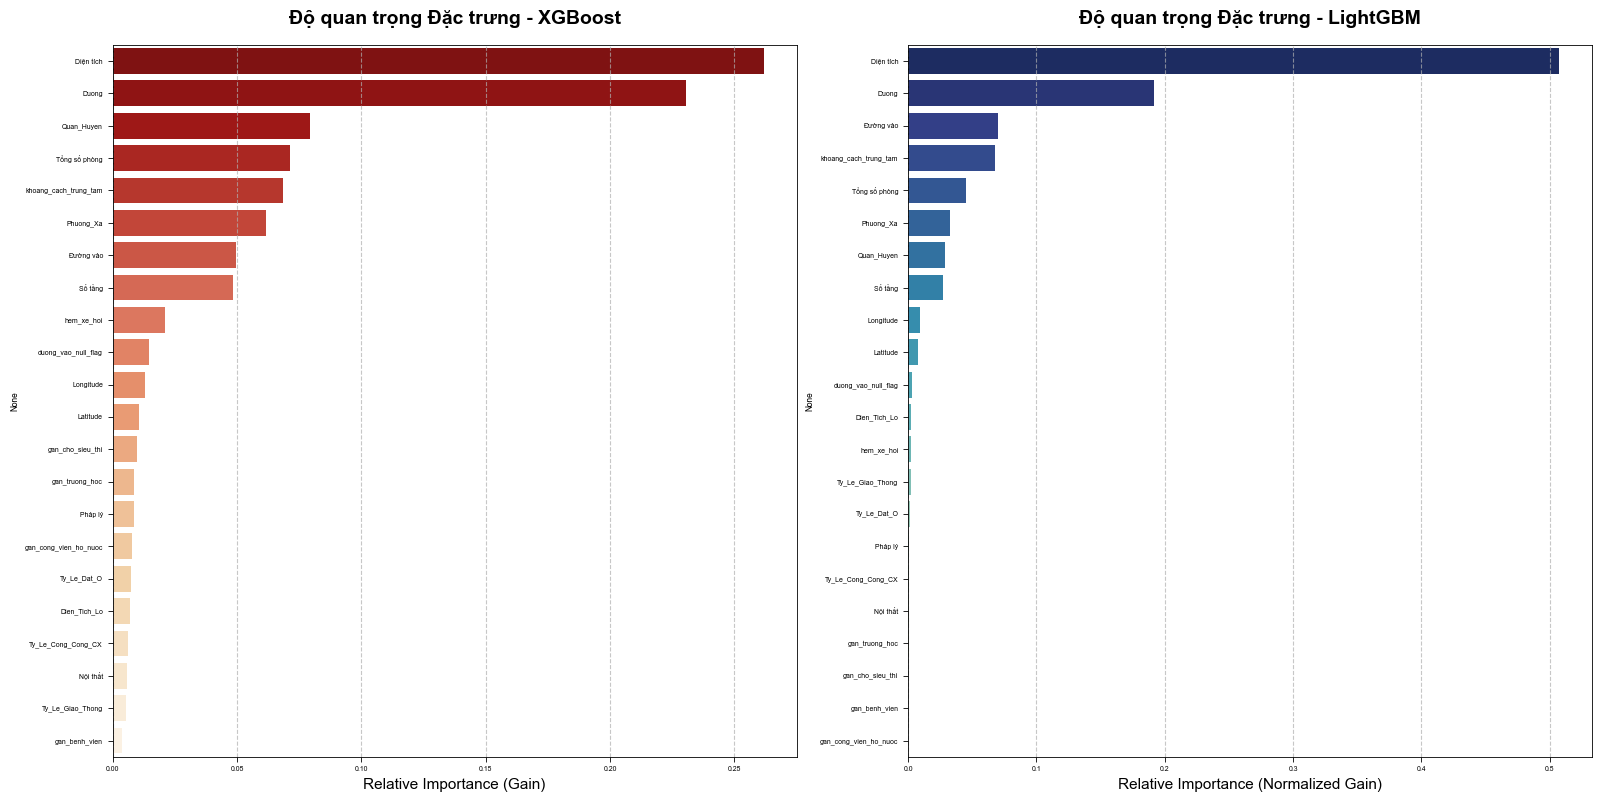

BẢNG SO SÁNH TRỌNG SỐ ĐẶC TRƯNG (XGBOOST VS LIGHTGBM):
------------------------------------------------------------
                       XGBoost  LightGBM
Diện tích               0.2619    0.5075
Duong                   0.2303    0.1914
Quan_Huyen              0.0792    0.0285
Tổng số phòng           0.0715    0.0451
khoang_cach_trung_tam   0.0686    0.0676
Phuong_Xa               0.0616    0.0328
Đường vào               0.0498    0.0699
Số tầng                 0.0484    0.0268
hem_xe_hoi              0.0211    0.0019
duong_vao_null_flag     0.0144    0.0033
Longitude               0.0131    0.0090
Latitude                0.0106    0.0075
gan_cho_sieu_thi        0.0097    0.0002
gan_truong_hoc          0.0086    0.0004
Pháp lý                 0.0084    0.0010
gan_cong_vien_ho_nuoc   0.0078    0.0001
Ty_Le_Dat_O             0.0072    0.0011
Dien_Tich_Lo            0.0068    0.0023
Ty_Le_Cong_Cong_CX      0.0062    0.0008
Nội thất                0.0056    0.0008
Ty_Le_Giao_Thong       

In [115]:
# =======================================================================
# CELL 6: FEATURE SELECTION - XGBOOST & LIGHTGBM IMPORTANCE
# =======================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Đang huấn luyện XGBoost và LightGBM để chấm điểm Đặc trưng...\n")

# Lưu ý: Code này sử dụng lại tập X_rf và y_rf đã được làm sạch ở Cell 5
X_boost = X_rf.copy()
y_boost = y_rf.copy()

# -------------------------------------------------------------------------
# 1. HUẤN LUYỆN VÀ TRÍCH XUẤT ĐIỂM TỪ XGBOOST
# -------------------------------------------------------------------------
# Cấu hình XGBoost cơ bản
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_boost, y_boost)

# Lấy feature importance (mặc định của XGBoost là 'gain' - mức độ cải thiện sai số)
xgb_importances = xgb_model.feature_importances_
xgb_scores = pd.Series(xgb_importances, name="XGBoost Importance", index=X_boost.columns)
xgb_scores = xgb_scores.sort_values(ascending=False)

# -------------------------------------------------------------------------
# 2. HUẤN LUYỆN VÀ TRÍCH XUẤT ĐIỂM TỪ LIGHTGBM
# -------------------------------------------------------------------------
# Cấu hình LightGBM. Sử dụng importance_type='gain' để tương đồng với XGBoost và RF
lgb_model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, importance_type='gain')
lgb_model.fit(X_boost, y_boost)

# Lấy feature importance và chuẩn hóa về dải 0-1 (tổng = 1) để dễ so sánh với XGBoost
lgb_importances = lgb_model.feature_importances_
lgb_importances_normalized = lgb_importances / lgb_importances.sum()
lgb_scores = pd.Series(lgb_importances_normalized, name="LightGBM Importance", index=X_boost.columns)
lgb_scores = lgb_scores.sort_values(ascending=False)

# -------------------------------------------------------------------------
# 3. TRỰC QUAN HÓA SO SÁNH (1 HÀNG, 2 CỘT)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Biểu đồ XGBoost
sns.barplot(x=xgb_scores.values, y=xgb_scores.index, ax=axes[0], palette="OrRd_r")
axes[0].set_title("Độ quan trọng Đặc trưng - XGBoost", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Relative Importance (Gain)", fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Biểu đồ LightGBM
sns.barplot(x=lgb_scores.values, y=lgb_scores.index, ax=axes[1], palette="YlGnBu_r")
axes[1].set_title("Độ quan trọng Đặc trưng - LightGBM", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Relative Importance (Normalized Gain)", fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 4. TỔNG HỢP BẢNG XẾP HẠNG CHÉO (CROSS-VALIDATION)
# -------------------------------------------------------------------------
# Gộp kết quả của XGBoost và LightGBM vào 1 dataframe để dễ so sánh
comparison_df_train = pd.DataFrame({
    'XGBoost': xgb_scores,
    'LightGBM': lgb_scores
}).fillna(0) # Điền 0 nếu có biến không xuất hiện trong top của mô hình kia

print("BẢNG SO SÁNH TRỌNG SỐ ĐẶC TRƯNG (XGBOOST VS LIGHTGBM):")
print("-" * 60)
print(comparison_df_train.sort_values(by='XGBoost', ascending=False).round(4))

Đang vẽ Scatter Plots cho 3678 dòng dữ liệu hợp lệ...



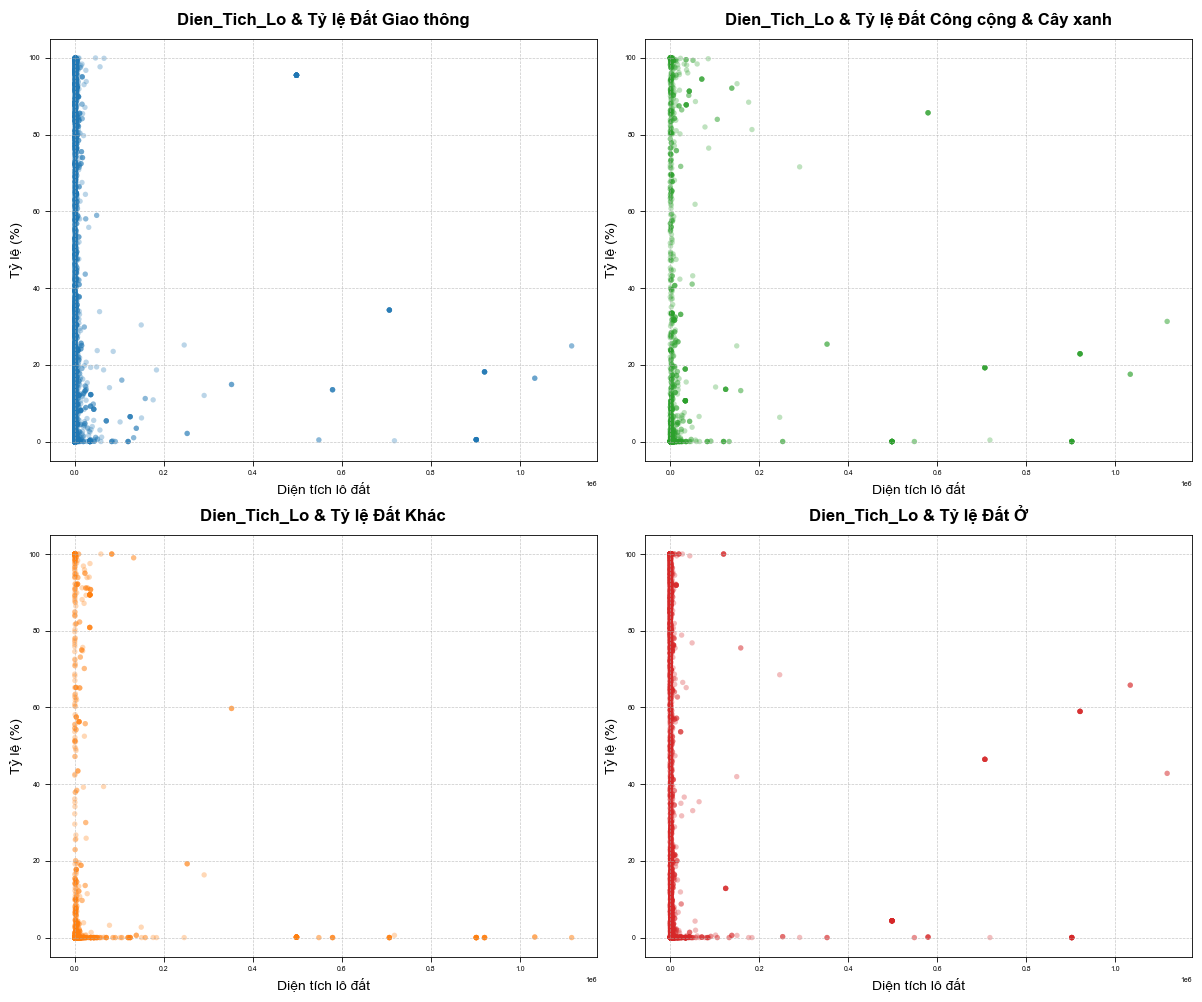

In [116]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -------------------------------------------------------------------------
# 1. CHUẨN BỊ DỮ LIỆU
# -------------------------------------------------------------------------
x_var = 'Dien_Tich_Lo'
y_vars = ['Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac', 'Ty_Le_Dat_O']

# Trích xuất các cột cần thiết và copy để tránh cảnh báo SettingWithCopyWarning
plot_data = df_train[[x_var] + y_vars].copy()

# Ép kiểu dữ liệu về dạng số thực (loại bỏ các giá trị lỗi/text nếu có)
for col in plot_data.columns:
    plot_data[col] = pd.to_numeric(plot_data[col], errors='coerce')

# Bỏ qua các dòng chứa NaN
plot_data = plot_data.dropna()

print(f"Đang vẽ Scatter Plots cho {len(plot_data)} dòng dữ liệu hợp lệ...\n")

# -------------------------------------------------------------------------
# 2. CẤU HÌNH VÀ VẼ LƯỚI BIỂU ĐỒ (2x2)
# -------------------------------------------------------------------------
# Thiết lập font chữ chuẩn
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

# Khởi tạo lưới 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Dải màu riêng biệt cho 4 loại tỷ lệ
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
titles = [
    'Tỷ lệ Đất Giao thông', 
    'Tỷ lệ Đất Công cộng & Cây xanh', 
    'Tỷ lệ Đất Khác', 
    'Tỷ lệ Đất Ở'
]

# Lặp qua 4 biến y để vẽ cùng với x (Dien_Tich_Lo)
for i, y_col in enumerate(y_vars):
    sns.scatterplot(
        data=plot_data, 
        x=x_var, 
        y=y_col, 
        color=colors[i],
        alpha=0.3,         # Độ trong suốt giúp nhận diện vùng mật độ cao
        edgecolor='none',  # Bỏ viền để các chấm không đè nát lên nhau
        s=15,              # Kích thước điểm ảnh
        ax=axes[i]
    )
    
    # Căn chỉnh tiêu đề và nhãn
    axes[i].set_title(f'{x_var} & {titles[i]}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Diện tích lô đất', fontsize=10)
    axes[i].set_ylabel(f'Tỷ lệ (%)' if plot_data[y_col].max() > 1.5 else 'Tỷ lệ (0.0 - 1.0)', fontsize=10)
    axes[i].grid(axis='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Căn chỉnh tự động khoảng cách
plt.tight_layout()
plt.show()

 Đang vẽ Boxplot tương quan cho 8 biến phân loại với biến mục tiêu 'Khoảng giá'...


/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/1452874259.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/1452874259.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/1452874259.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/1452874259.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

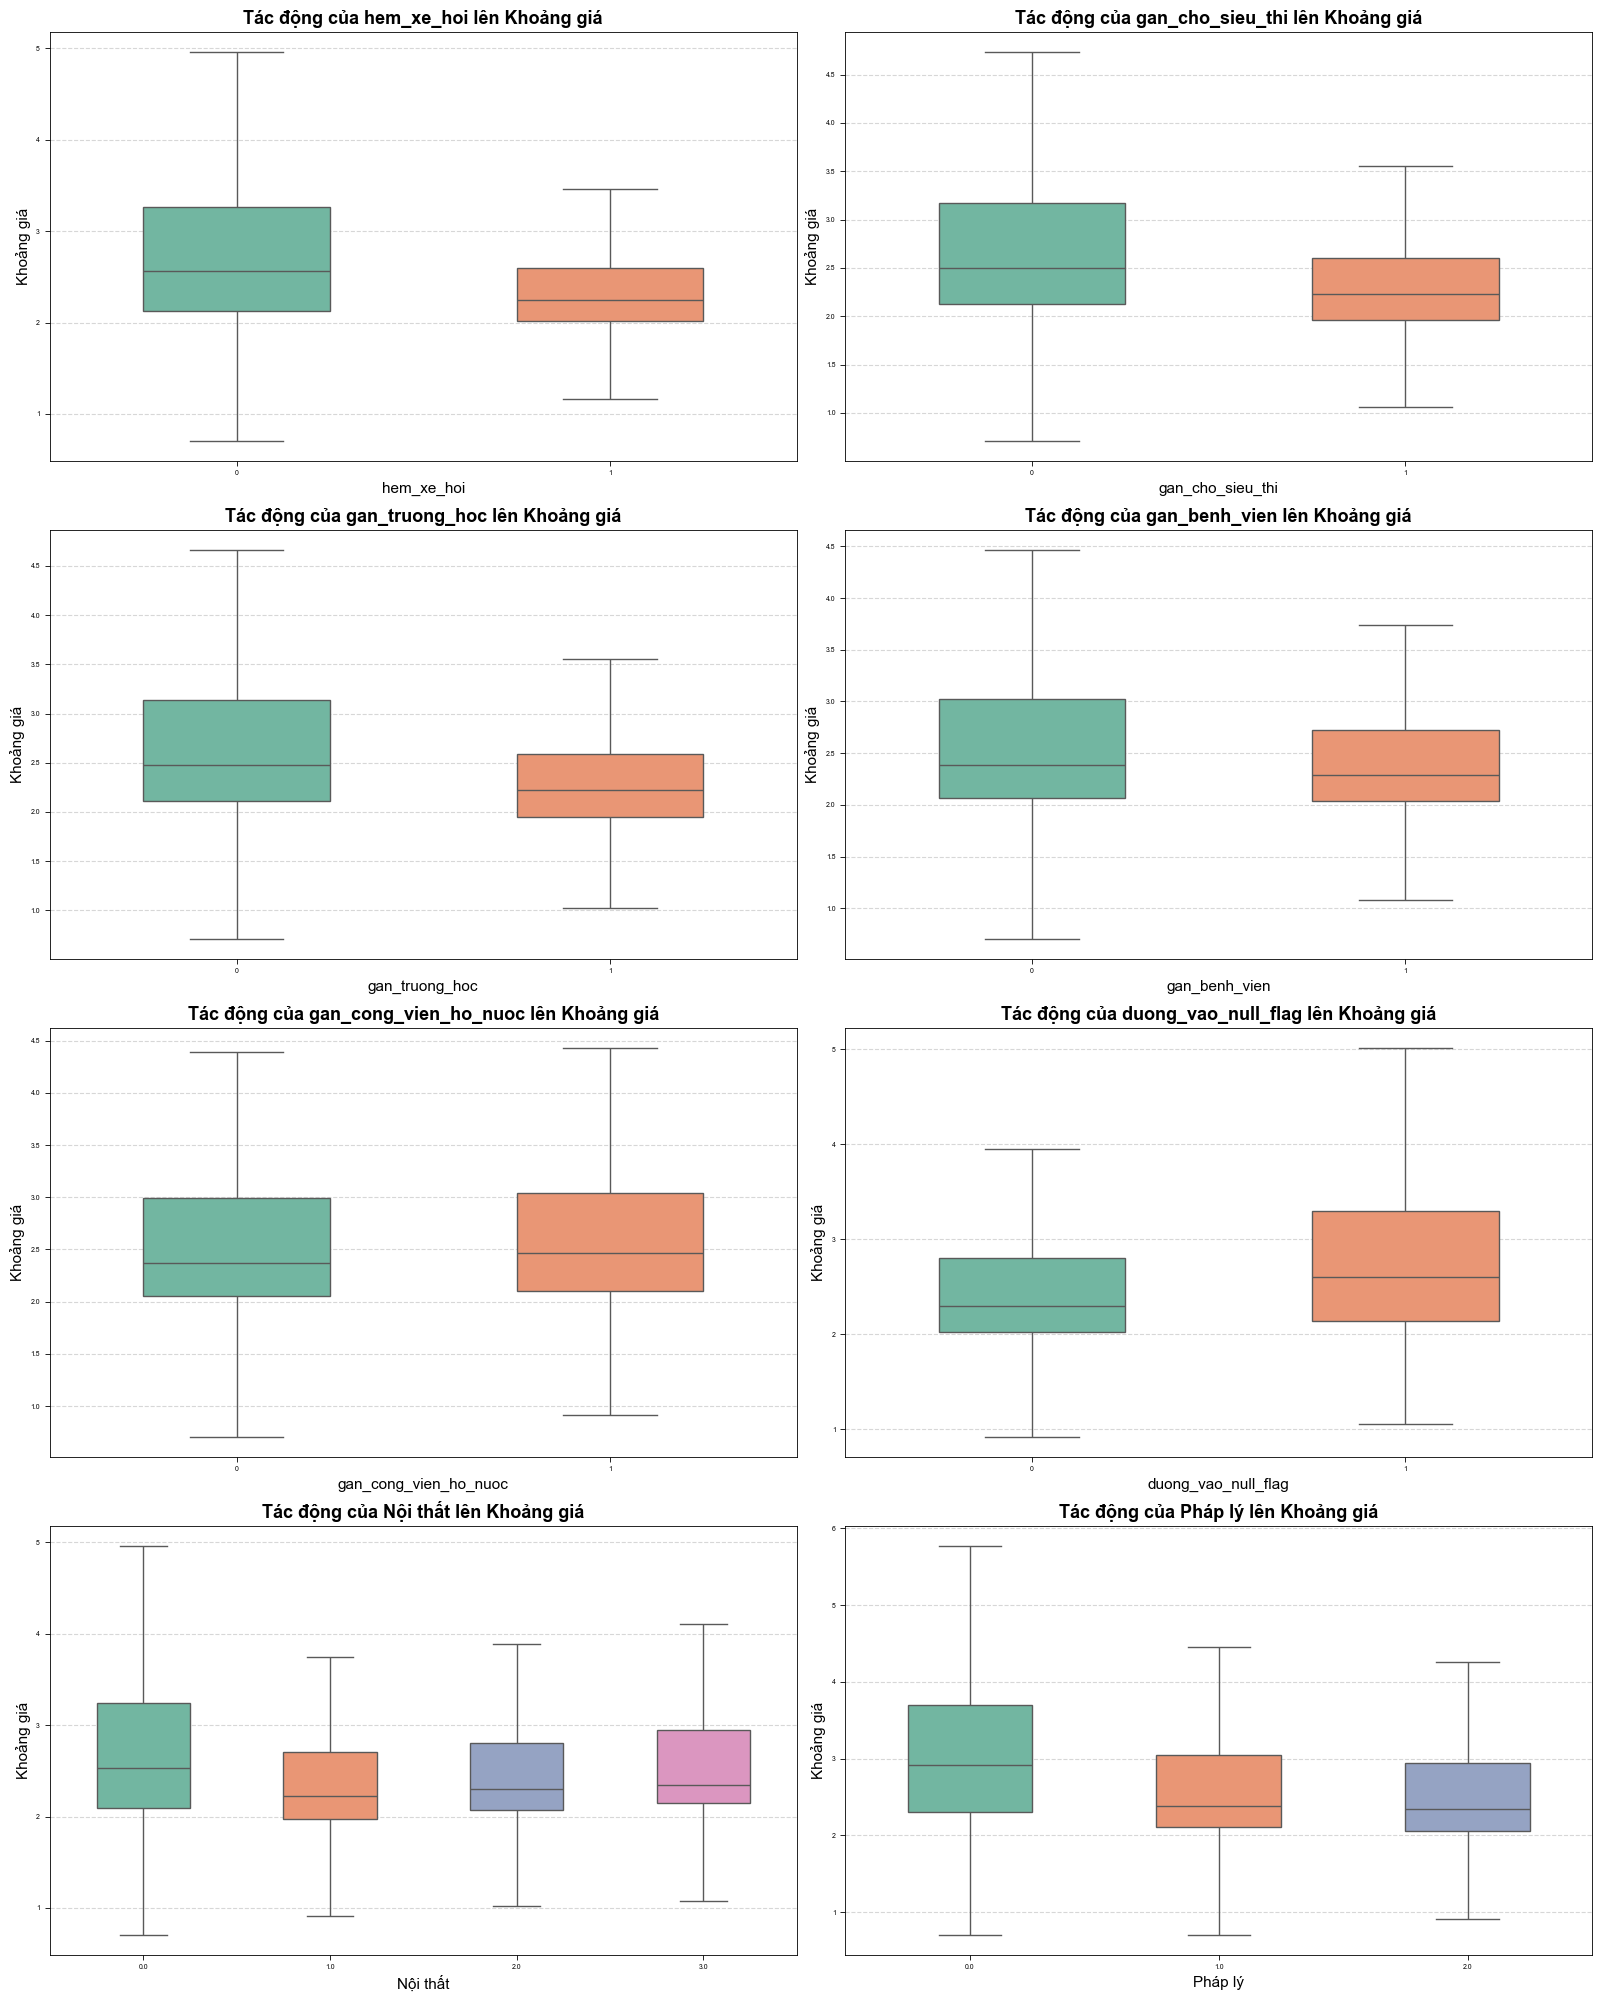

In [117]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -------------------------------------------------------------------------
# 1. KHAI BÁO BIẾN
# -------------------------------------------------------------------------
target = "Khoảng giá"  # Bây giờ đóng vai trò là biến số học liên tục (Trục Y)

cat_cols = [
    "hem_xe_hoi",
    "gan_cho_sieu_thi",
    "gan_truong_hoc",
    "gan_benh_vien",
    "gan_cong_vien_ho_nuoc",
    "duong_vao_null_flag",
    "Nội thất",
    "Pháp lý"
]

# Lọc các cột thực sự tồn tại
valid_cat_cols = [col for col in cat_cols if col in df_train.columns]

# Đảm bảo biến mục tiêu đã được ép về kiểu số
df_train[target] = pd.to_numeric(df_train[target], errors="coerce")

# -------------------------------------------------------------------------
# 2. VẼ ĐỒ THỊ BOXPLOT THEO LƯỚI
# -------------------------------------------------------------------------
if len(valid_cat_cols) > 0:
    print(
        f" Đang vẽ Boxplot tương quan cho {len(valid_cat_cols)} biến phân loại với biến mục tiêu '{target}'..."
    )

    n_cols = 2
    n_rows = int(np.ceil(len(valid_cat_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(valid_cat_cols):
        # Vẽ boxplot: X là biến phân loại (0/1), Y là giá trị liên tục (Khoảng giá)
        sns.boxplot(
            data=df_train,
            x=col,
            y=target,
            ax=axes[i],
            palette="Set2",
            width=0.5,
            showfliers=False,  # Đặt thành True nếu bạn muốn nhìn thấy các chấm ngoại lai (Outliers)
        )

        # Tinh chỉnh giao diện
        axes[i].set_title(
            f"Tác động của {col} lên {target}", fontsize=13, fontweight="bold"
        )
        axes[i].set_xlabel(col, fontsize=11)
        axes[i].set_ylabel(target, fontsize=11)
        axes[i].grid(axis="y", linestyle="--", alpha=0.5)

    # Ẩn các ô thừa
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy biến phân loại phù hợp.")

In [118]:
df_train = df_train.drop(columns = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Ty_Le_Khac'])
df_test = df_test.drop(columns = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Ty_Le_Khac'])

Phân khúc giá dao động khoảng 20,52 tỷ nhưng có độ lệch chuẩn cao tới 38 tỷ nhưng chủ yếu về bên phải => bị ảnh hướng bỏi các căn có giá đắt đỏ

Outliers do các căn có mức giá trăm tỷ đẩy giá thị trường làm biến động sự phân hóa nhưng những căn này ko phải outliers do các lỗi nhập liệu mà do tồn tại những căn được rao bán được coi như siêu biệt thự

Giá nhà ảnh hướng có độ tương quan không quá cao vô giá nhà vì tồn tại 3 phân khúc, nhà có ít tầng nhưng lại thuộc dạng biệt phủ hoặc do giá đất quá cao, nhà nhiều tầng thuộc các căn rao bán bất động sản, mức ở giữa thì giá sẽ tăng dựa trên số tầng và phòng -> đây là những căn giá tăng thực sự do 2 biến này


PHẦN 16: PHÂN TÍCH TÁC ĐỘNG TẤT CẢ BIẾN SỐ ĐẾN GIÁ (KHOẢNG GIÁ)

[✓] Phân tích 22 biến số
    Các biến: ['Diện tích', 'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo']...

[BẢNG TÓMSỦT] TÁC ĐỘNG CỦA TẤT CẢ BIẾN SỐ:
                  Feature  Correlation  Price_Ratio_Q4_Q1  Impact_%  Count
0               Diện tích       0.6404             1.6657     66.57   4645
2               Đường vào       0.5967             1.6154     61.54   4645
8                   Duong       0.5587             1.5674     56.74   4645
11          Tổng số phòng       0.5468             1.5615     56.15   4645
6               Phuong_Xa       0.4838             1.4752     47.52   4645
1                 Số tầng       0.4499             1.4148     41.48   4645
5              Quan_Huyen       0.4348             1.4452     44.52   4645
12  khoang_cach_trung_tam      -0.3191             0.7571    -24.29   4645
4               Longitude       0.1416      

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/3618425356.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_quartile = target_valid.groupby(quartile_labels).agg(['mean', 'median', 'count'])
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/3618425356.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_quartile = target_valid.groupby(quartile_labels).agg(['mean', 'median', 'count'])
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_27358/3618425356.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a f

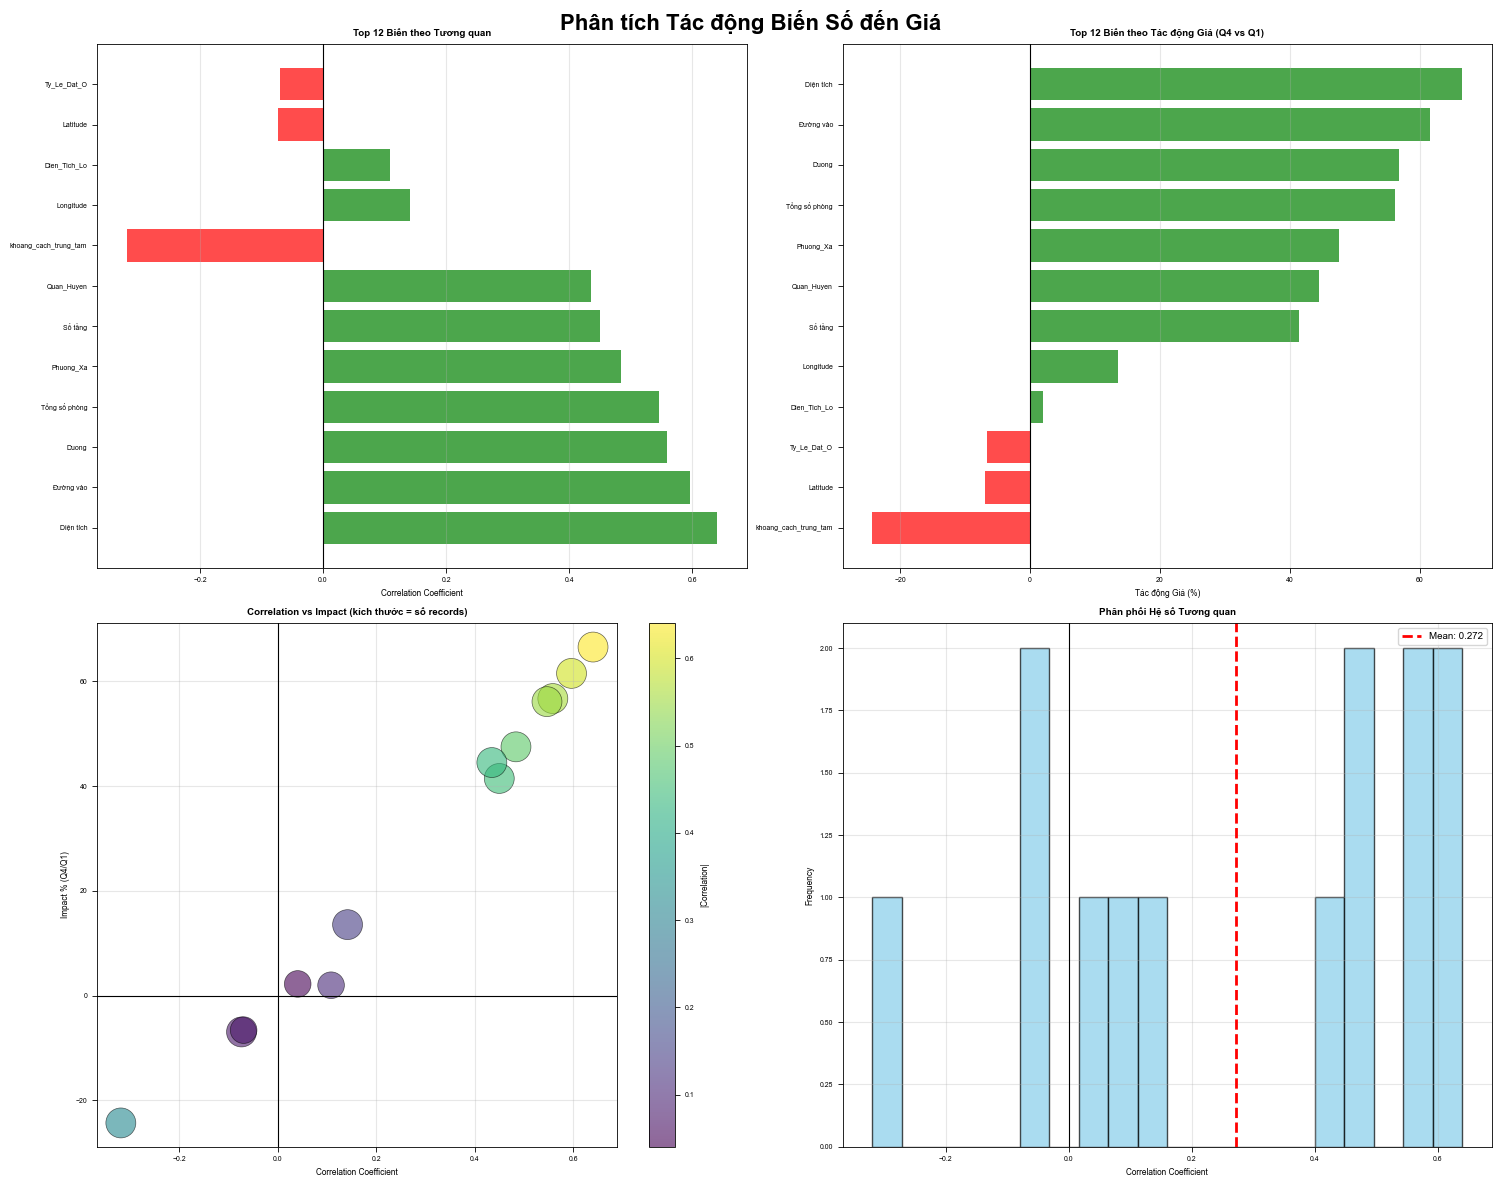


[THỐNG KÊ] Tổng hợp Tương quan:
    - Trung bình: 0.2722
    - Median: 0.4348
    - Std Dev: 0.3143
    - Min: -0.3191
    - Max: 0.6404

[CHI TIẾT] Top 15 Biến có Tác động mạnh nhất:
              Feature  Correlation  Price_Ratio_Q4_Q1  Impact_%  Price_Avg  Price_Min  Price_Max  Count
            Diện tích       0.6404             1.6657     66.57   2.602647   0.703098   6.552508   4645
            Đường vào       0.5967             1.6154     61.54   2.602647   0.703098   6.552508   4645
                Duong       0.5587             1.5674     56.74   2.602647   0.703098   6.552508   4645
        Tổng số phòng       0.5468             1.5615     56.15   2.602647   0.703098   6.552508   4645
            Phuong_Xa       0.4838             1.4752     47.52   2.602647   0.703098   6.552508   4645
              Số tầng       0.4499             1.4148     41.48   2.602647   0.703098   6.552508   4645
           Quan_Huyen       0.4348             1.4452     44.52   2.602647   0.703098  

In [119]:

# ============================================================================
# PHẦN 16: PHÂN TÍCH TOÀN DIỆN TÁC ĐỘNG CỦA TẤT CẢ BIẾN SỐ ĐẾN LABEL
# ============================================================================

print("\n" + "="*80)
print("PHẦN 16: PHÂN TÍCH TÁC ĐỘNG TẤT CẢ BIẾN SỐ ĐẾN GIÁ (KHOẢNG GIÁ)")
print("="*80)

# Xác định target
target_col = 'Khoảng giá'
target_data = df_train[target_col]

# Lấy danh sách tất cả các biến số
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

print(f"\n[✓] Phân tích {len(numeric_cols)} biến số")
print(f"    Các biến: {numeric_cols[:10]}..." if len(numeric_cols) > 10 else f"    Các biến: {numeric_cols}")

# Tạo bảng tóm tắt tác động của tất cả biến số
impact_summary_numeric = []

for col in numeric_cols:
    try:
        # Loại bỏ NaN
        valid_mask = df_train[col].notna() & df_train[target_col].notna()
        col_data = df_train.loc[valid_mask, col]
        target_valid = df_train.loc[valid_mask, target_col]
        
        # Tính toán thống kê
        correlation = col_data.corr(target_valid)
        
        # Tìm quartiles
        q1, q2, q3 = col_data.quantile([0.25, 0.5, 0.75])
        
        # Giá trung bình theo quartiles
        quartile_labels = pd.qcut(col_data, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
        price_by_quartile = target_valid.groupby(quartile_labels).agg(['mean', 'median', 'count'])
        
        # Tính tỷ lệ giá Q4/Q1 để thấy tác động
        if len(price_by_quartile) >= 2:
            price_ratio = price_by_quartile.loc['Q4', 'mean'] / price_by_quartile.loc['Q1', 'mean'] if price_by_quartile.loc['Q1', 'mean'] > 0 else 0
            price_diff_pct = (price_ratio - 1) * 100
        else:
            price_ratio = 0
            price_diff_pct = 0
        
        impact_summary_numeric.append({
            'Feature': col,
            'Count': col_data.count(),
            'Min': col_data.min(),
            'Max': col_data.max(),
            'Mean': col_data.mean(),
            'Correlation': round(correlation, 4),
            'Price_Avg': target_valid.mean(),
            'Price_Min': target_valid.min(),
            'Price_Max': target_valid.max(),
            'Price_Ratio_Q4_Q1': round(price_ratio, 4),
            'Impact_%': round(price_diff_pct, 2)
        })
    except Exception as e:
        continue

impact_df_train = pd.DataFrame(impact_summary_numeric)
# Sắp xếp theo tương quan tuyệt đối
impact_df_train['Abs_Correlation'] = impact_df_train['Correlation'].abs()
impact_df_train = impact_df_train.sort_values('Abs_Correlation', ascending=False)

print("\n[BẢNG TÓMSỦT] TÁC ĐỘNG CỦA TẤT CẢ BIẾN SỐ:")
print(impact_df_train[['Feature', 'Correlation', 'Price_Ratio_Q4_Q1', 'Impact_%', 'Count']].to_string())

# Visualize tương quan
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Phân tích Tác động Biến Số đến Giá', fontsize=16, fontweight='bold')

# 1. Top 12 biến theo tương quan
ax = axes[0, 0]
top_corr = impact_df_train.head(12)
colors_corr = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors_corr, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'])
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Top 12 Biến theo Tương quan', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# 2. Top 12 biến theo tác động giá (Impact %)
ax = axes[0, 1]
impact_top = impact_df_train.head(12).sort_values('Impact_%', ascending=True)
colors_impact = ['green' if x > 0 else 'red' for x in impact_top['Impact_%']]
ax.barh(range(len(impact_top)), impact_top['Impact_%'], color=colors_impact, alpha=0.7)
ax.set_yticks(range(len(impact_top)))
ax.set_yticklabels(impact_top['Feature'])
ax.set_xlabel('Tác động Giá (%)')
ax.set_title('Top 12 Biến theo Tác động Giá (Q4 vs Q1)', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# 3. Scatter plot: Correlation vs Impact
ax = axes[1, 0]
scatter = ax.scatter(impact_df_train['Correlation'], impact_df_train['Impact_%'], 
                     s=impact_df_train['Count']/10, alpha=0.6, c=impact_df_train['Abs_Correlation'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Impact % (Q4/Q1)')
ax.set_title('Correlation vs Impact (kích thước = số records)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.colorbar(scatter, ax=ax, label='|Correlation|')

# 4. Distribution của tương quan
ax = axes[1, 1]
ax.hist(impact_df_train['Correlation'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(x=impact_df_train['Correlation'].mean(), color='red', linestyle='--', 
           label=f'Mean: {impact_df_train["Correlation"].mean():.3f}', linewidth=2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Phân phối Hệ số Tương quan', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[THỐNG KÊ] Tổng hợp Tương quan:")
print(f"    - Trung bình: {impact_df_train['Correlation'].mean():.4f}")
print(f"    - Median: {impact_df_train['Correlation'].median():.4f}")
print(f"    - Std Dev: {impact_df_train['Correlation'].std():.4f}")
print(f"    - Min: {impact_df_train['Correlation'].min():.4f}")
print(f"    - Max: {impact_df_train['Correlation'].max():.4f}")

# Tạo bảng chi tiết cho top 15 biến
print("\n[CHI TIẾT] Top 15 Biến có Tác động mạnh nhất:")
detailed_cols = ['Feature', 'Correlation', 'Price_Ratio_Q4_Q1', 'Impact_%', 
                 'Price_Avg', 'Price_Min', 'Price_Max', 'Count']
print(impact_df_train[detailed_cols].head(15).to_string(index=False))



CELL 21: PHÂN TÍCH TƯƠNG TÁC GIỮA CUNG (SỐ LƯỢNG) VÀ BIẾN ĐỘNG GIÁ
[+] Chỉ số toán học thu được:
    - Tương quan giữa Số lượng & Mức giá Trung vị: r = 0.254
    - Tương quan giữa Số lượng & Biên độ dao động giá: r = 0.303


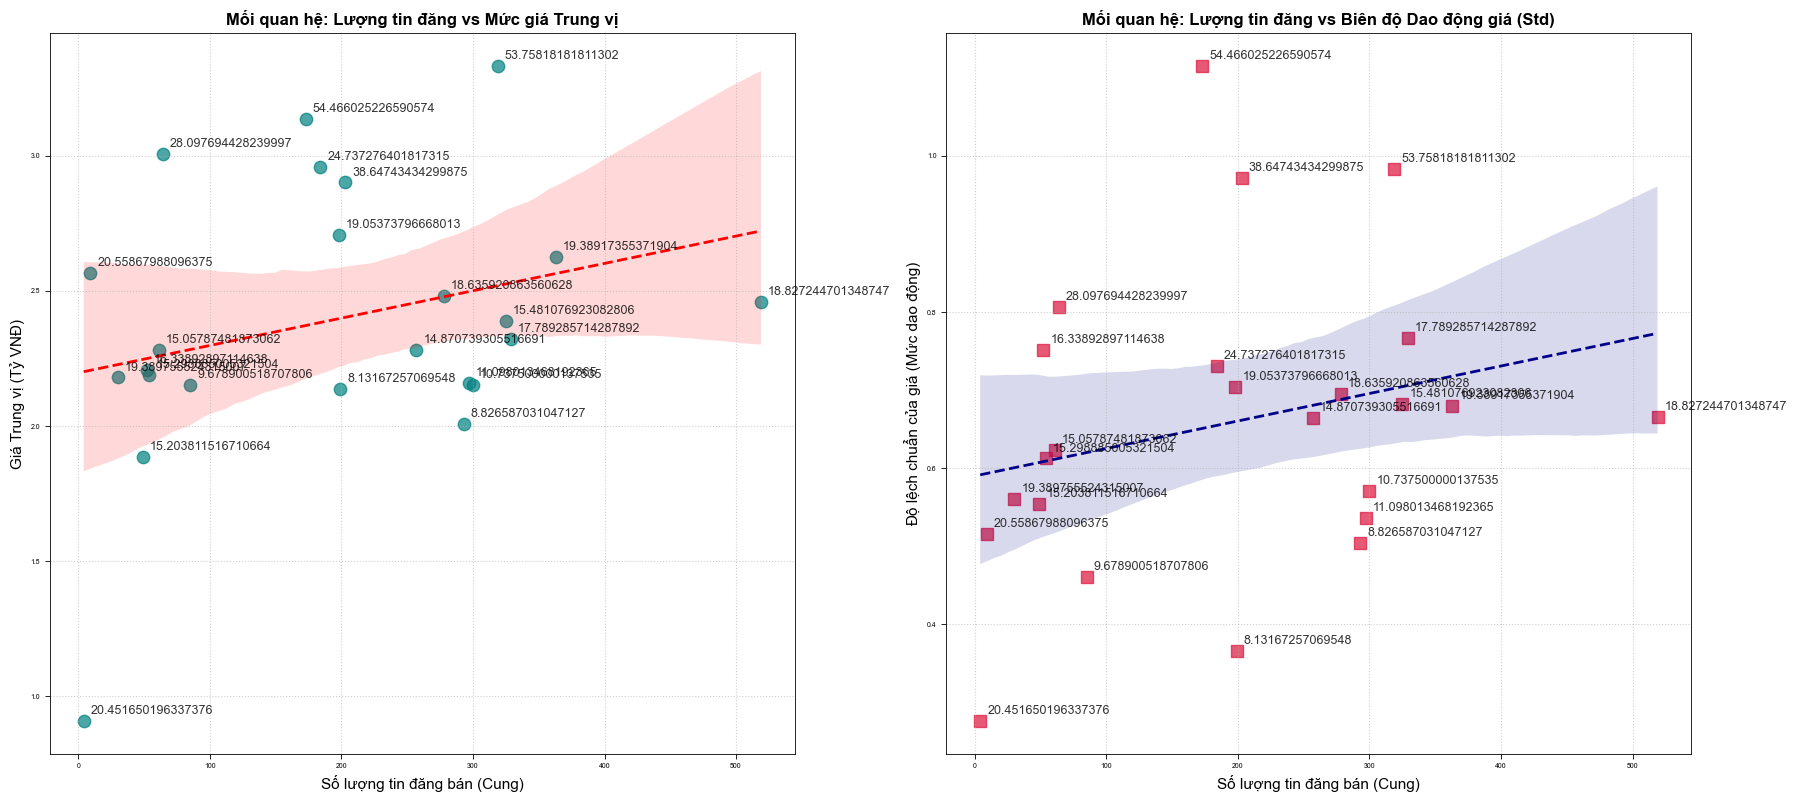

In [120]:
# CELL 16: Deep Relational Analysis - Supply (Volume) vs Price Volatility (Volatility)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("CELL 21: PHÂN TÍCH TƯƠNG TÁC GIỮA CUNG (SỐ LƯỢNG) VÀ BIẾN ĐỘNG GIÁ")
print("="*80)

target_col = 'Khoảng giá'
district_col = 'Quan_Huyen'

# -------------------------------------------------------------------------
# BƯỚC 1: GỘP DỮ LIỆU CẤP QUẬN - ĐỊNH NGHĨA "SỐ LƯỢNG" VÀ "DAO ĐỘNG GIÁ"
# -------------------------------------------------------------------------
# Dao động giá được đo bằng:
# - Độ lệch chuẩn (Std): Mức độ phân tán của giá so với trung bình.
# - IQR (Interquartile Range): Biên độ giá của 50% phân khúc lõi (Ít bị nhiễu bởi siêu biệt thự).
market_relation = df_train.groupby(district_col).agg(
    So_Luong_Tin_Dang=(target_col, 'count'),
    Gia_Trung_Vi=(target_col, 'median'),
    Do_Lech_Chuan_Gia=(target_col, 'std'),
    IQR_Gia=(target_col, lambda x: x.quantile(0.75) - x.quantile(0.25))
).reset_index().fillna(0)

# -------------------------------------------------------------------------
# BƯỚC 2: TÍNH TOÁN HỆ SỐ TƯƠNG QUAN TOÁN HỌC (SPEARMAN)
# -------------------------------------------------------------------------
corr_volume_price = market_relation['So_Luong_Tin_Dang'].corr(market_relation['Gia_Trung_Vi'], method='spearman')
corr_volume_volatility = market_relation['So_Luong_Tin_Dang'].corr(market_relation['Do_Lech_Chuan_Gia'], method='spearman')

print(f"[+] Chỉ số toán học thu được:")
print(f"    - Tương quan giữa Số lượng & Mức giá Trung vị: r = {corr_volume_price:.3f}")
print(f"    - Tương quan giữa Số lượng & Biên độ dao động giá: r = {corr_volume_volatility:.3f}")


# -------------------------------------------------------------------------
# BƯỚC 3: TRỰC QUAN HÓA BẰNG ĐỒ THỊ PHÂN TÁN (SCATTER PLOT + REGRESSION LINE)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Đồ thị 1: Số lượng tin đăng vs Mức giá Trung vị
sns.regplot(
    data=market_relation,
    x='So_Luong_Tin_Dang',
    y='Gia_Trung_Vi',
    ax=axes[0],
    color='teal',
    marker='o',
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
)
axes[0].set_title('Mối quan hệ: Lượng tin đăng vs Mức giá Trung vị', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng tin đăng bán (Cung)', fontsize=11)
axes[0].set_ylabel('Giá Trung vị (Tỷ VNĐ)', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gắn tên quận lên từng chấm tròn ở Đồ thị 1
for idx, row in market_relation.iterrows():
    axes[0].annotate(row[district_col], (row['So_Luong_Tin_Dang'], row['Gia_Trung_Vi']),
                     textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, alpha=0.8)


# Đồ thị 2: Số lượng tin đăng vs Biên độ Dao động giá (Độ lệch chuẩn)
sns.regplot(
    data=market_relation,
    x='So_Luong_Tin_Dang',
    y='Do_Lech_Chuan_Gia',
    ax=axes[1],
    color='crimson',
    marker='s',
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'color': 'darkblue', 'linewidth': 2, 'linestyle': '--'}
)
axes[1].set_title('Mối quan hệ: Lượng tin đăng vs Biên độ Dao động giá (Std)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng tin đăng bán (Cung)', fontsize=11)
axes[1].set_ylabel('Độ lệch chuẩn của giá (Mức dao động)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Gắn tên quận lên từng chấm vuông ở Đồ thị 2
for idx, row in market_relation.iterrows():
    axes[1].annotate(row[district_col], (row['So_Luong_Tin_Dang'], row['Do_Lech_Chuan_Gia']),
                     textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, alpha=0.8)

plt.tight_layout()
plt.show()

Giá trị của các căn được rao bán phụ thuộc vô số lượng bài đăng & gần quận trung tâm => thể hiện thị trường nhộn nhịp với tiện ích mặc dù được rao bán nhiều trong cùng quận nhưng vẫn giữu dược mức giá khá cao do nhu cầu lớn, variance của giá cao xuất hiện ở các quận 1 và gần trung tâm vì kinh tế phát triển => xuất hiện 1 số biệt thự với tòa mặt tiền để kéo giá thị trường lên

# Lưu dữ liệu

In [121]:
# =======================================================================
# CELL 7: XUẤT VÀ LƯU TRỮ DỮ LIỆU ĐÃ LÀM SẠCH (EXPORT CLEANED DATA)
# =======================================================================
import os

# 2. Lưu df_train và df_test ra file CSV
# Sử dụng index=False để Pandas không tự động sinh ra thêm một cột số thứ tự vô nghĩa
df_train.to_csv(file_path_train, index=False, encoding='utf-8-sig')
df_test.to_csv(file_path_test, index=False, encoding='utf-8-sig')

# 3. Kiểm tra lại dung lượng file để xác nhận
train_size = os.path.getsize(file_path_train) / (1024 * 1024) # Đổi sang MB
test_size = os.path.getsize(file_path_test) / (1024 * 1024)   # Đổi sang MB

print("-" * 50)
print(f"✅ Đã lưu thành công tập Train vào: {file_path_train} ({train_size:.2f} MB)")
print(f"✅ Đã lưu thành công tập Test vào:  {file_path_test} ({test_size:.2f} MB)")
print("Dữ liệu đã sẵn sàng để đưa vào huấn luyện mô hình XGBoost/LightGBM!")

--------------------------------------------------
✅ Đã lưu thành công tập Train vào: /Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/Đồ án/DS108/notebook/data_output/3_data_preprocessed_linear_train.csv (1.14 MB)
✅ Đã lưu thành công tập Test vào:  /Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/Đồ án/DS108/notebook/data_output/3_data_preprocessed_linear_test.csv (0.29 MB)
Dữ liệu đã sẵn sàng để đưa vào huấn luyện mô hình XGBoost/LightGBM!
